# Film Success Prediction (Capstone Final Project)
# Step 2: EDA (Exploratory Data Analysis) & Feature Engineering

## Data Cleaning & Preparaion complete - Next:

1. Validate data quality (missingness, ranges, outliers)
2. Understand relationships between business drivers (budget, genre, year, runtime) and outcomes (revenue, audience signals)
3. Produce stakeholder-friendly visuals with clear labels and takeaways


In [1]:
# Core
import os
from pathlib import Path
import numpy as np
import pandas as pd

# Viz
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

# Sklearn
from sklearn.model_selection import train_test_split, KFold, StratifiedKFold, GridSearchCV, cross_validate
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    mean_absolute_error, mean_squared_error, r2_score,
    accuracy_score, f1_score, roc_auc_score, classification_report, confusion_matrix, ConfusionMatrixDisplay,
    RocCurveDisplay
)

import warnings
warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 120)

PROJECT_DIR = Path(".").resolve()
DATA_DIR = PROJECT_DIR / "sample_data"
DATA_DIR.mkdir(exist_ok=True)


## 1) Load cleaned dataset

In [2]:

df = pd.read_csv(DATA_DIR / "movies_modeling_dataset.csv")
df.head()


,id,title,budget,revenue,runtime,release_year,genres,original_language,popularity,vote_average,vote_count,status,primary_genre,has_budget,has_revenue,roi
0,19995,Avatar,237000000,2787965087,162.0,2009.0,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...",en,150.437577,7.2,11800,Released,Action,1,1,11.763566
1,285,Pirates of the Caribbean: At World's End,300000000,961000000,169.0,2007.0,"[{""id"": 12, ""name"": ""Adventure""}, {""id"": 14, ""...",en,139.082615,6.9,4500,Released,Adventure,1,1,3.203333
2,206647,Spectre,245000000,880674609,148.0,2015.0,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...",en,107.376788,6.3,4466,Released,Action,1,1,3.594590
3,49026,The Dark Knight Rises,250000000,1084939099,165.0,2012.0,"[{""id"": 28, ""name"": ""Action""}, {""id"": 80, ""nam...",en,112.312950,7.6,9106,Released,Action,1,1,4.339756
4,49529,John Carter,260000000,284139100,132.0,2012.0,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...",en,43.926995,6.1,2124,Released,Action,1,1,1.092843


## 2) Quick data quality checks

In [3]:

print("Rows:", len(df))
display(df.isna().mean().sort_values(ascending=False).head(10))

# Ensure expected dtypes
df.dtypes


Rows: 3226


,0
id,0.0
title,0.0
budget,0.0
revenue,0.0
runtime,0.0
release_year,0.0
genres,0.0
original_language,0.0
popularity,0.0
vote_average,0.0


,0
id,int64
title,object
budget,int64
revenue,int64
runtime,float64
release_year,float64
genres,object
original_language,object
popularity,float64
vote_average,float64


## 3) Continuous variable distributions

In [4]:

numeric_cols = ["budget", "revenue", "runtime", "vote_average", "vote_count", "popularity", "roi"]
df[numeric_cols].describe().T


,count,mean,std,min,25%,50%,75%,max
budget,3226.0,4.067641e+07,4.441006e+07,1.000000e+00,1.050000e+07,2.500000e+07,5.500000e+07,3.800000e+08
revenue,3226.0,1.213329e+08,1.863634e+08,5.000000e+00,1.702004e+07,5.519150e+07,1.464463e+08,2.787965e+09
runtime,3226.0,1.106085e+02,2.044674e+01,4.100000e+01,9.600000e+01,1.070000e+02,1.210000e+02,2.380000e+02
vote_average,3226.0,6.309516e+00,8.739393e-01,0.000000e+00,5.800000e+00,6.300000e+00,6.900000e+00,8.500000e+00
vote_count,3226.0,9.781348e+02,1.414693e+03,0.000000e+00,1.782500e+02,4.710000e+02,1.148000e+03,1.375200e+04
popularity,3226.0,2.905622e+01,3.617453e+01,1.998400e-02,1.047564e+01,2.042190e+01,3.735080e+01,8.755813e+02
roi,3226.0,2.957569e+03,1.506801e+05,5.217391e-07,1.025658e+00,2.301077e+00,4.420995e+00,8.500000e+06


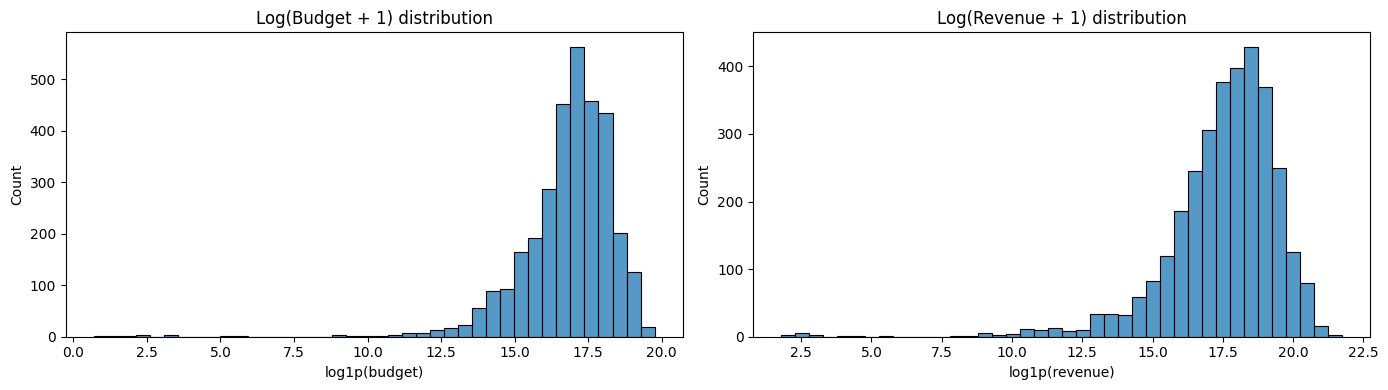

In [5]:

# Use log-scale views for heavy-tailed variables like budget and revenue
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

sns.histplot(np.log1p(df["budget"]), bins=40, ax=axes[0])
axes[0].set_title("Log(Budget + 1) distribution")
axes[0].set_xlabel("log1p(budget)")

sns.histplot(np.log1p(df["revenue"]), bins=40, ax=axes[1])
axes[1].set_title("Log(Revenue + 1) distribution")
axes[1].set_xlabel("log1p(revenue)")

plt.tight_layout()
plt.show()


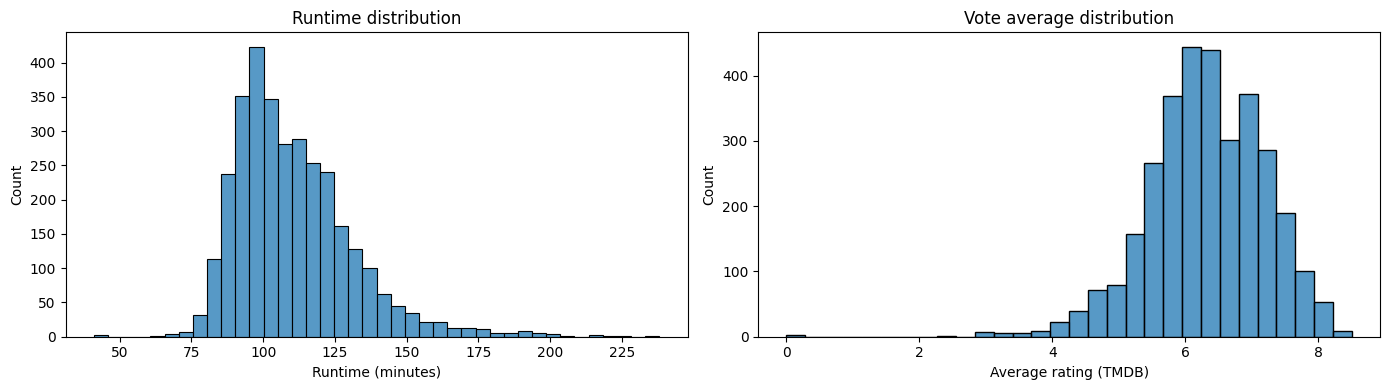

In [6]:

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

sns.histplot(df["runtime"].dropna(), bins=40, ax=axes[0])
axes[0].set_title("Runtime distribution")
axes[0].set_xlabel("Runtime (minutes)")

sns.histplot(df["vote_average"].dropna(), bins=30, ax=axes[1])
axes[1].set_title("Vote average distribution")
axes[1].set_xlabel("Average rating (TMDB)")

plt.tight_layout()
plt.show()


## 4) Categorical variables

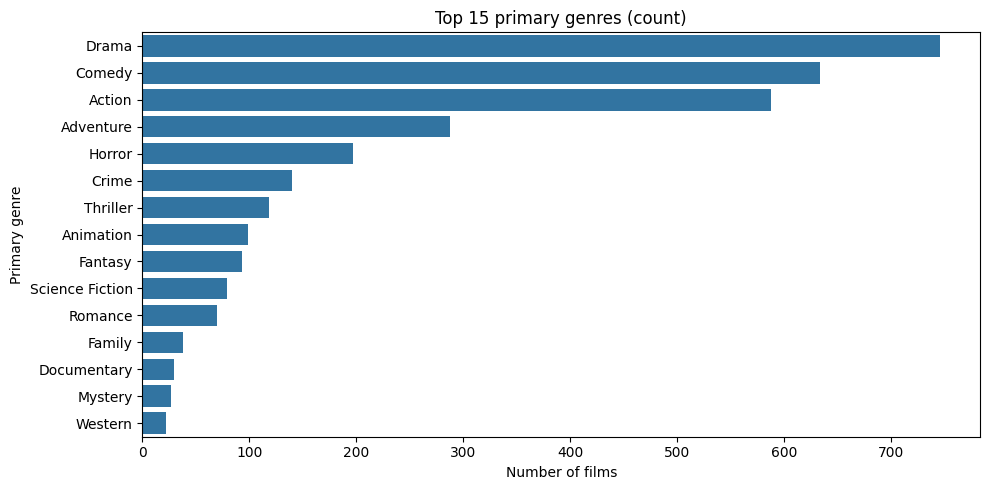

In [7]:

top_genres = df["primary_genre"].value_counts().head(15)

plt.figure(figsize=(10, 5))
sns.barplot(x=top_genres.values, y=top_genres.index)
plt.title("Top 15 primary genres (count)")
plt.xlabel("Number of films")
plt.ylabel("Primary genre")
plt.tight_layout()
plt.show()


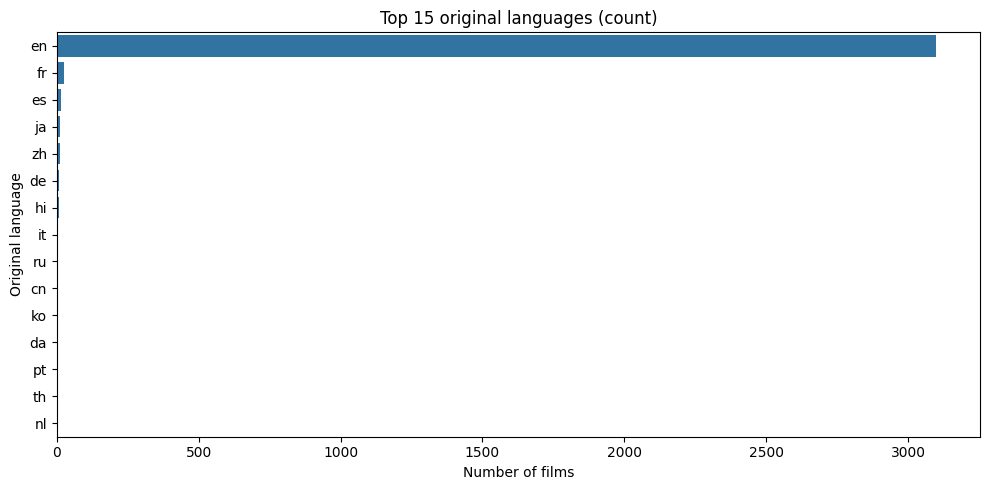

In [8]:

lang_counts = df["original_language"].value_counts().head(15)

plt.figure(figsize=(10, 5))
sns.barplot(x=lang_counts.values, y=lang_counts.index)
plt.title("Top 15 original languages (count)")
plt.xlabel("Number of films")
plt.ylabel("Original language")
plt.tight_layout()
plt.show()


## 5) Relationships between key drivers and outcomes

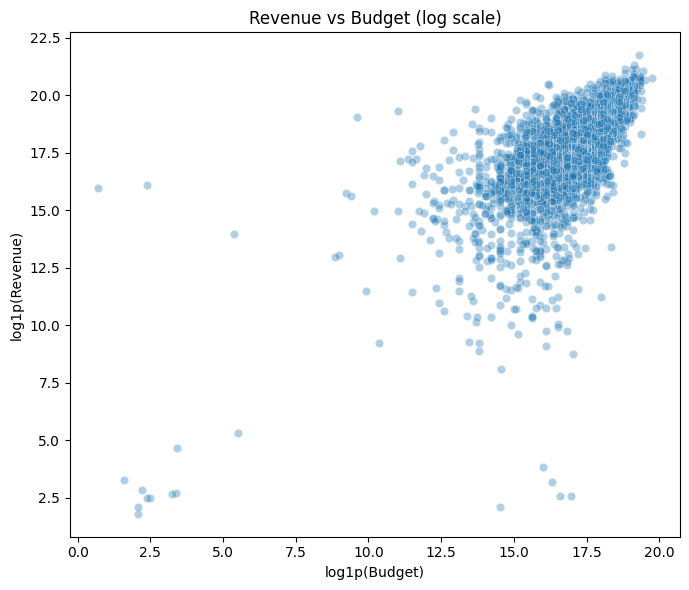

In [9]:

# Budget vs revenue (log scale)
plt.figure(figsize=(7, 6))
sns.scatterplot(x=np.log1p(df["budget"]), y=np.log1p(df["revenue"]), alpha=0.35)
plt.title("Revenue vs Budget (log scale)")
plt.xlabel("log1p(Budget)")
plt.ylabel("log1p(Revenue)")
plt.tight_layout()
plt.show()


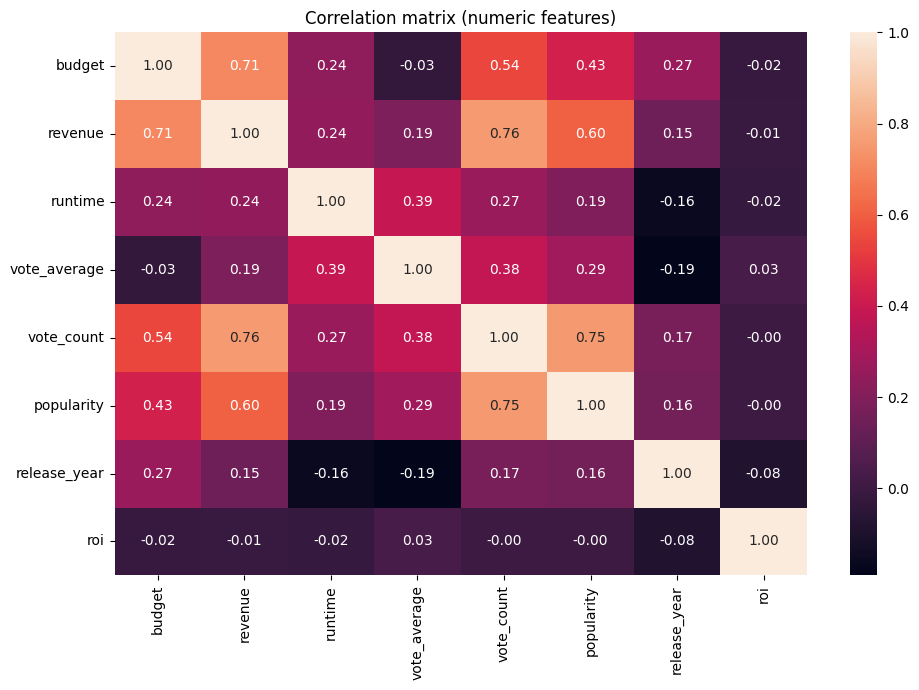

In [10]:

# Correlation heatmap for numeric variables
corr_cols = ["budget", "revenue", "runtime", "vote_average", "vote_count", "popularity", "release_year", "roi"]
corr = df[corr_cols].corr()

plt.figure(figsize=(10, 7))
sns.heatmap(corr, annot=True, fmt=".2f")
plt.title("Correlation matrix (numeric features)")
plt.tight_layout()
plt.show()


In [11]:

# Genre-level summary: median budget, median revenue, median ROI
genre_summary = (
    df.groupby("primary_genre", as_index=False)
      .agg(
          n=("title", "count"),
          median_budget=("budget", "median"),
          median_revenue=("revenue", "median"),
          median_roi=("roi", "median"),
          median_vote_avg=("vote_average", "median"),
          median_vote_count=("vote_count", "median"),
      )
      .query("n >= 20")
      .sort_values("median_roi", ascending=False)
)

genre_summary.head(10)


,primary_genre,n,median_budget,median_revenue,median_roi,median_vote_avg,median_vote_count
11,Horror,197,10800000.0,44196684.0,3.727743,5.90,492.0
18,Western,22,5250000.0,15100000.0,2.929273,7.20,271.5
15,Science Fiction,79,35000000.0,96085477.0,2.842603,6.40,1091.0
7,Family,38,47500000.0,95268400.5,2.817984,6.20,573.5
5,Documentary,30,2276824.0,7674743.5,2.726874,6.95,69.0
1,Adventure,288,60000000.0,140974137.5,2.654669,6.35,926.0
2,Animation,99,76000000.0,245724603.0,2.637818,6.50,978.0
13,Mystery,27,22000000.0,42333295.0,2.493711,6.30,512.0
3,Comedy,634,20000000.0,46547728.5,2.421409,6.10,380.0
14,Romance,70,23000000.0,61274473.5,2.315841,6.55,431.0


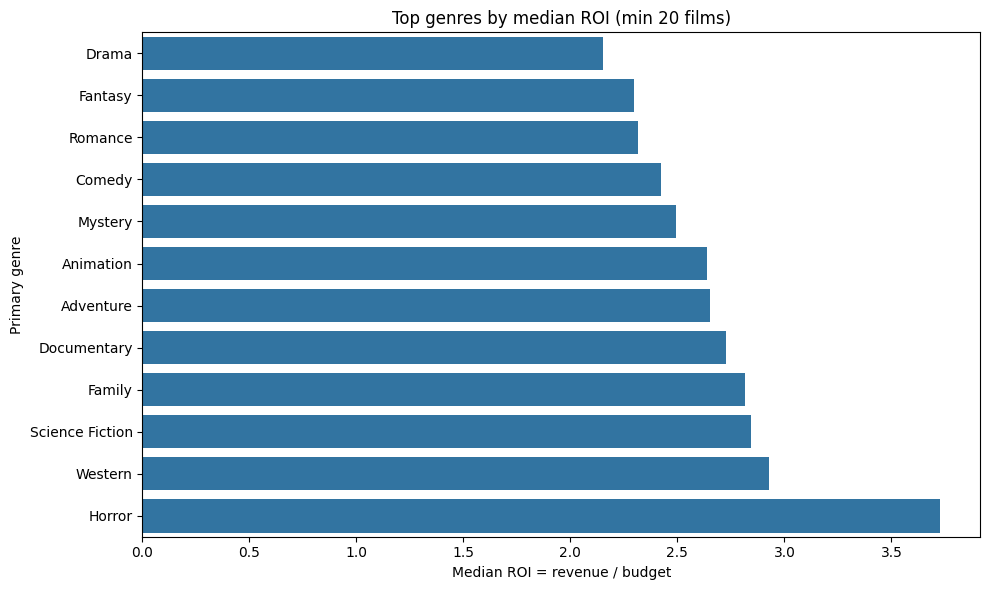

In [12]:

plt.figure(figsize=(10, 6))
top_roi = genre_summary.head(12).sort_values("median_roi", ascending=True)
sns.barplot(x=top_roi["median_roi"], y=top_roi["primary_genre"])
plt.title("Top genres by median ROI (min 20 films)")
plt.xlabel("Median ROI = revenue / budget")
plt.ylabel("Primary genre")
plt.tight_layout()
plt.show()


## 6) Interactive plot (Plotly): budget, revenue, genre

In [ ]:

fig = px.scatter(
    df,
    x="budget",
    y="revenue",
    color="primary_genre",
    hover_data=["title", "release_year", "vote_average", "vote_count"],
    title="Budget vs Revenue (interactive)",
    log_x=True,
    log_y=True
)
fig.show()


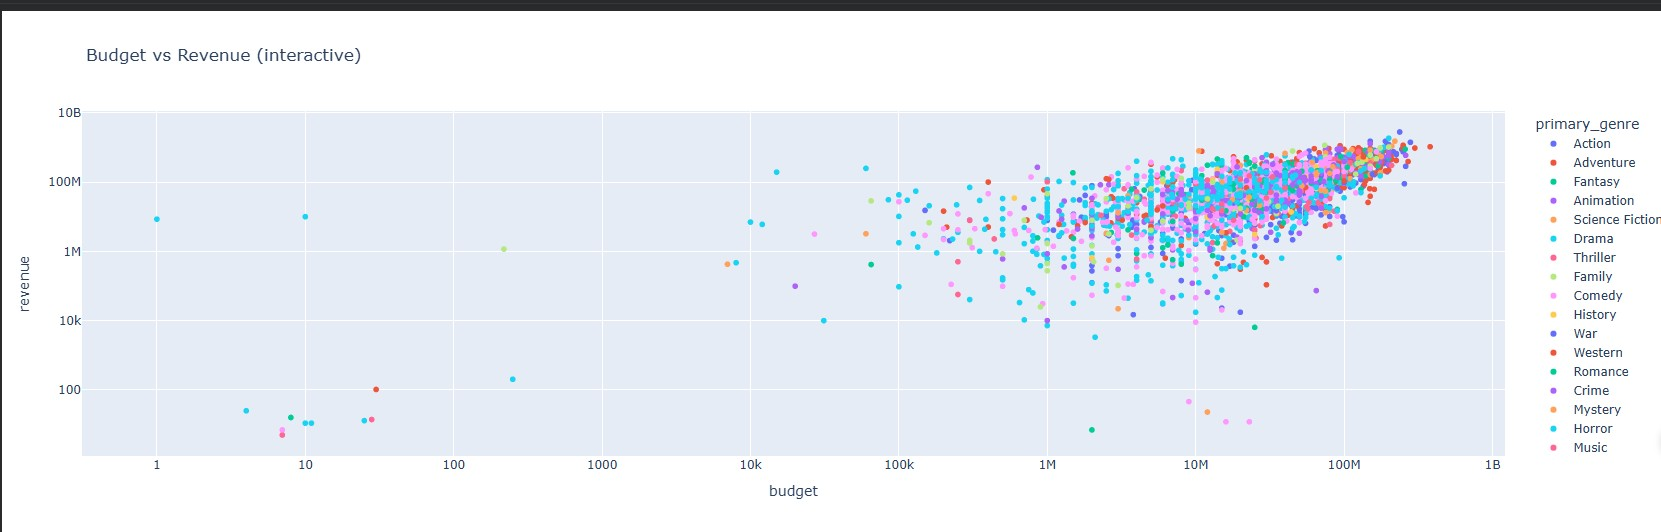

## 7) Feature engineering for modeling

In [14]:

df_fe = df.copy()

# Transform heavy-tailed features for modeling
df_fe["log_budget"] = np.log1p(df_fe["budget"])
df_fe["log_popularity"] = np.log1p(df_fe["popularity"])
df_fe["log_vote_count"] = np.log1p(df_fe["vote_count"])

# Drop raw heavy-tailed versions (optional) — keep them if you want
# We'll keep raw + logs to let the model decide.
df_fe[["title", "budget", "log_budget", "vote_count", "log_vote_count"]].head()


,title,budget,log_budget,vote_count,log_vote_count
0,Avatar,237000000,19.283571,11800,9.375940
1,Pirates of the Caribbean: At World's End,300000000,19.519293,4500,8.412055
2,Spectre,245000000,19.316769,4466,8.404472
3,The Dark Knight Rises,250000000,19.336971,9106,9.116799
4,John Carter,260000000,19.376192,2124,7.661527


## 8) Save feature-engineered dataset

In [16]:

out_path = DATA_DIR / "movies_feature_engineered.csv"
df_fe.to_csv(out_path, index=False)
print(f"Saved: {out_path} (rows={len(df_fe):,}, cols={df_fe.shape[1]})")


Saved: /content/sample_data/movies_feature_engineered.csv (rows=3,226, cols=19)


A new feature-engineered dataset has been saved in Colab. This will be used in the next step (next Jupyter Notebook) of modeling multiple regression models.

## Key EDA takeaways

- **Budget and revenue are strongly related**, but the relationship is noisy: big budgets do not guarantee big revenue.
- **Genre matters**: different genres tend to have different typical budgets and returns.
- **Audience engagement measures** (vote counts and popularity) are strongly associated with revenue, but may partially reflect post-release effects (marketing reach and distribution).


